-----------------RAW DATASET SUMMARY-------------------------
The raw dataset contains regent scores of 1012 schools. School level ranges are
 ['K-8' 'High school' 'Junior High-Intermediate-Middle' 'Secondary School'
 'K-12 all grades' 'Elementary'], for the academic years [2017 2015 2016]. Subject includes ['Common Core Algebra' 'Living Environment' 'Common Core English'
 'Algebra2/Trigonometry' 'Common Core Algebra2' 'Common Core Geometry'
 'English' 'Geometry' 'Global History and Geography' 'Integrated Algebra'
 'Physical Settings/Chemistry' 'Physical Settings/Earth Science'
 'U.S. History and Government' 'Physical Settings/Physics' nan].
 Examples of some schools includes: ['P.S. 034 Franklin D. Roosevelt' 'P.S. 140 Nathan Straus'
 'P.S. 184m Shuang Wen']

-----------------PROJECT DATASET SUMMARY-------------------------
For the following analysis, we will compare regent performance of Marta Valle High School to that
 of the citywide high schools for 2015-2017.



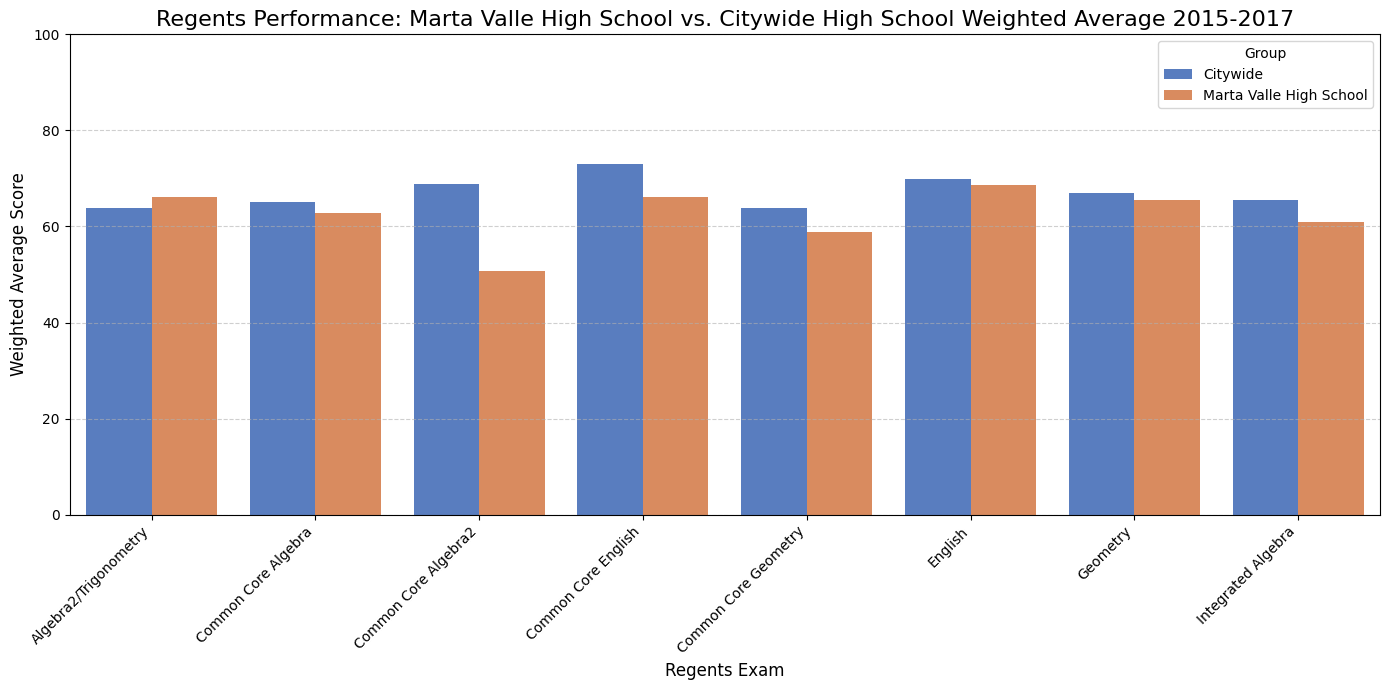




Based on the graph, Marta Valle High School is underperformed compared to the citywide high schools.
* Best Performance: Algebra2/Trigonometry (Gap: 3.38%)
* Worst Performance: Common Core Algebra2 (Gap: -26.27%)
Subjects that are outperformed are: Algebra2/Trigonometry
Subjects that are underperformed are: Common Core Algebra, Common Core Algebra2, Common Core English, Common Core Geometry, English, Geometry, Integrated Algebra



In [7]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#define function
def get_weighted_avg(df,value,weight,group):
  temp_df=df.copy()
  temp_df['top'] =  temp_df[value]* temp_df[weight]
  temp_df['bottom'] =  temp_df[weight]
  result_df =  temp_df.groupby(group).agg({'top': 'sum','bottom': 'sum'}).reset_index()
  result_df['weight_mean'] = result_df['top']/result_df['bottom']
  return result_df.drop(['top', 'bottom'], axis=1)

#load data
url = 'https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv'
df = pd.read_csv(url)

# _______________________________________________________________________
# #checking dataset and get familiar with dataset
# #check a small sample of dataset
# df.info()
# print(df.head(10))

# #summary of dataset
unique_years = df['Year'].unique()
unique_school = df['School Name'].unique()
school_level= df['School Level'].unique()
subject= df['Regents Exam'].unique()
print("-----------------RAW DATASET SUMMARY-------------------------")
print(f"""The raw dataset contains regent scores of {len(unique_school)} schools. School level ranges are
 {school_level}, for the academic years {unique_years}. Subject includes {subject}.
 Examples of some schools includes: {unique_school[0:3]}""" )
print()
# #chosen benchmark school
print("-----------------PROJECT DATASET SUMMARY-------------------------")
benchmark_school = 'Marta Valle High School'
print(f"""For the following analysis, we will compare regent performance of {benchmark_school} to that
 of the citywide high schools for 2015-2017.""")
print()
# #population dataset
high_school_df = df[df['School Level']=='High school'].copy()

# bronx = df[df['School DBN'].str.contains('x', case=False, na=False)]
# print(bronx.head(10))
# print(f"Total High School rows: {len(high_school_df)}")


# _______________________________________________________________________
# #data cleaning
# #after checking data type and a few row of population dataset,
# #there are rows with number but marked as string type and some rows are 's'

# #list all columns that should be numeric but marked as string
cols = [
    'Total Tested',
    'Mean Score',
    'Number Scoring Below 65',
    'Percent Scoring Below 65',
    'Number Scoring 65 or Above',
    'Percent Scoring 65 or Above',
    'Number Scoring 80 or Above',
    'Percent Scoring 80 or Above',
    'Number Scoring CR',
    'Percent Scoring CR'
    ]

# use for loop to convert to numeric and change 's' to NaN
for i in cols:
    high_school_df[i] = pd.to_numeric(high_school_df[i], errors='coerce')

# _______________________________________________________________________
# data analysis
# #because not every year has score, so i calculated weighted average to combine average for the three years
# #formula for weight average = sum(mean*total_tested)/sum(total_tested) or top/total_tested
# #population/high school group analysis

clean_hs_df = high_school_df.dropna(subset=cols).copy()
clean_hs_df['top'] = clean_hs_df['Mean Score'] * clean_hs_df['Total Tested']

hs_stat_df = clean_hs_df.groupby(['Regents Exam']).agg({'top': 'sum', 'Total Tested': 'sum'}).reset_index()

hs_stat_df['weighted_mean']=hs_stat_df['top']/hs_stat_df['Total Tested']
hs_stat_df = hs_stat_df[['Regents Exam', 'Total Tested', 'weighted_mean']]

# #benchmark school analysis
benchmark_school_df=clean_hs_df[clean_hs_df['School Name']==benchmark_school]
benchmark_school_stat_df=get_weighted_avg(benchmark_school_df,'Mean Score','Total Tested','Regents Exam')

# _______________________________________________________________________
# visualization

# merge the tables
combined_df = pd.merge(
    hs_stat_df[['Regents Exam', 'weighted_mean']],
    benchmark_school_stat_df[['Regents Exam', 'weight_mean']],
    on='Regents Exam'
)

# rename columns for the legend
combined_df.columns = ['Regents Exam', 'Citywide', benchmark_school]

# calculate gap difference between benchmark school and citywide
combined_df['Gap_Percentage'] = ((combined_df[benchmark_school] - combined_df['Citywide']) / combined_df['Citywide']) * 100

# print(combined_df)
# change dataset from wide to long format
plot_data = combined_df.melt(
    id_vars='Regents Exam',
    value_vars=['Citywide',benchmark_school],
    var_name='Category',
    value_name='Weighted Average'
)
# print(combined_df)
# print(plot_data)

plt.figure(figsize=(14, 7))

# create the bar chart
ax = sns.barplot(
    data=plot_data,
    x='Regents Exam',
    y='Weighted Average',
    hue='Category',
    palette='muted'
)

# styling the graph
plt.title(f'Regents Performance: {benchmark_school} vs. Citywide High School Weighted Average 2015-2017', fontsize=16)
plt.ylabel('Weighted Average Score', fontsize=12)
plt.xlabel('Regents Exam', fontsize=12)
plt.xticks(rotation=45, ha='right') # rotates labels so they don't overlap
plt.ylim(0, 100) # sets y-axis to standard 0-100 scale
plt.grid(axis='y', linestyle='--', alpha=0.6)

# legend location
plt.legend(title='Group', loc='upper right')

plt.tight_layout()
plt.show()

print()
print()
print(f"""
Based on the graph, {benchmark_school} is {"outperformed" if combined_df['Gap_Percentage'].mean()>0 else "underperformed"} compared to the citywide high schools.
* Best Performance: {combined_df.loc[combined_df['Gap_Percentage'].idxmax(), 'Regents Exam']} (Gap: {combined_df['Gap_Percentage'].max():.2f}%)
* Worst Performance: {combined_df.loc[combined_df['Gap_Percentage'].idxmin(), 'Regents Exam']} (Gap: {combined_df['Gap_Percentage'].min():.2f}%)
Subjects that are outperformed are: {", ".join(combined_df[combined_df['Gap_Percentage']>=0]['Regents Exam'])}
Subjects that are underperformed are: {", ".join(combined_df[combined_df['Gap_Percentage']<0]['Regents Exam'])}
""")


